<a href="https://colab.research.google.com/github/aidadbeni/Computational-Pathology/blob/main/prov_gigapath_demo/ProvGigaPath_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
!git clone https://github.com/prov-gigapath/prov-gigapath.git
%cd prov-gigapath

Cloning into 'prov-gigapath'...
remote: Enumerating objects: 215, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 215 (delta 67), reused 50 (delta 46), pack-reused 115 (from 1)
Receiving objects: 100% (215/215), 7.90 MiB | 14.39 MiB/s, done.
Resolving deltas: 100% (90/90), done.
/content/prov-gigapath/demo/prov-gigapath


In [30]:
!ls

data	     environment.yaml  images	     pyproject.toml    scripts
dataset_csv  finetune	       LICENSE	     README.md
demo	     gigapath	       linear_probe  requirements.txt


In [31]:
! pip install -e .

Obtaining file:///content/prov-gigapath/demo/prov-gigapath
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for gigapath (pyproject.toml) ... done
  Created wheel for gigapath: filename=gigapath-0.1.0-0.editable-py3-none-any.whl size=12301 sha256=02eff428fdc278b4470fdf67977e121e01e3d8ae64e70040a4a6a7f21dc3bc8f
  Stored in directory: /tmp/pip-ephem-wheel-cache-hs52y62l/wheels/49/ad/62/ddd51ca1b8f0a661a63e70ccd4fce82be432b2c8e93ecdfdc0
Successfully built gigapath
  Attempting uninstall: gigapath
    Found existing installation: gigapath 0.1.0
    Uninstalling gigapath-0.1.0:
      Successfully uninstalled gigapath-0.1.0


In [32]:
!pip install "timm>=1.0.3"

In [33]:
from getpass import getpass
import os

os.environ["HF_TOKEN"] = getpass("Enter your Hugging Face token: ")

Enter your Hugging Face token: ··········


In [34]:
#importing open slide
!pip install openslide-python openslide-bin

In [35]:
import openslide

print("OpenSlide imported successfully!")

OpenSlide imported successfully!


In [36]:
#starting the demo
!python demo/1_slide_mpp_check.py


sample_data/PROV-000-000001.ndpi: downloading bytes: 100% 424M/424M [00:02<00:00, 236MB/s, 37.6MB/s  ]
sample_data/PROV-000-000001.ndpi: reconstructing file:  60% 256M/424M [00:02<00:01, 106MB/s]
sample_data/PROV-000-000001.ndpi: downloading bytes: 100% 424M/424M [00:02<00:00, 145MB/s, 38.1MB/s  ]
sample_data/PROV-000-000001.ndpi: reconstructing file: 100% 424M/424M [00:02<00:00, 145MB/s, 38.6MB/s  ]
NOTE: Prov-GigaPath is trained with 0.5 mpp preprocessed slides
<_PropertyMap {'hamamatsu.Area.Height.Macro': '-1', 'hamamatsu.Area.Width.Macro': '-1', 'hamamatsu.CCD.Height': '-1', 'hamamatsu.CCD.Width': '5303', 'hamamatsu.Calibration.Version': '500', 'hamamatsu.Coarse.Focus.Pitch': '5000', 'hamamatsu.Coarse.Focus.Travel': '10000', 'hamamatsu.Condenser.NA': 'ÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿ5', 'hamamatsu.Condition2.CCD.Height': '0', 'hamamatsu.Condition2.CCD.Width': '0', 'hamamatsu.Condition2.Lane.Shift.Amount': '0', 'hamamatsu.Condition2.Objective.Lens.Magnificant': '1.01857e-312', 'ham

this step has found tghe target resolution from the whole slide images in openslide.


In [37]:
#inspecting the codes
!cat demo/1_slide_mpp_check.py

import huggingface_hub
import os
from gigapath.preprocessing.data.slide_utils import find_level_for_target_mpp

assert "HF_TOKEN" in os.environ, "Please set the HF_TOKEN environment variable to your Hugging Face API token"

local_dir = os.path.join(os.path.expanduser("~"), ".cache/")
huggingface_hub.hf_hub_download("prov-gigapath/prov-gigapath", filename="sample_data/PROV-000-000001.ndpi", local_dir=local_dir, force_download=True)

slide_path = os.path.join(local_dir, "sample_data/PROV-000-000001.ndpi")

print("NOTE: Prov-GigaPath is trained with 0.5 mpp preprocessed slides")
target_mpp = 0.5
level = find_level_for_target_mpp(slide_path, target_mpp)
if level is not None:
    print(f"Found level: {level}")
else:
    print("No suitable level found.")


part 1 :
Import the tools I need.

Make sure I have permission to access Hugging Face.

Download this sample whole-slide pathology image.

Remember where I saved it.

Prov-GigaPath wants tissue at approximately 0.5 MPP.

Inspect this WSI and find which resolution level corresponds to approximately 0.5 MPP.

Tell me what you found.

In [38]:
#second part
!cat demo/2_tiling_demo.py

from gigapath.pipeline import tile_one_slide
import huggingface_hub
import os

assert "HF_TOKEN" in os.environ, "Please set the HF_TOKEN environment variable to your Hugging Face API token"

local_dir = os.path.join(os.path.expanduser("~"), ".cache/")
huggingface_hub.hf_hub_download("prov-gigapath/prov-gigapath", filename="sample_data/PROV-000-000001.ndpi", local_dir=local_dir, force_download=True)
slide_path = os.path.join(local_dir, "sample_data/PROV-000-000001.ndpi")

save_dir = os.path.join(local_dir, 'outputs/preprocessing/')

print("NOTE: Prov-GigaPath is trained with 0.5 mpp preprocessed slides. Please make sure to use the appropriate level for the 0.5 MPP")
tile_one_slide(slide_path, save_dir=save_dir, level=1)

print("NOTE: tiling dependency libraries can be tricky to set up. Please double check the generated tile images.")


In [39]:
#installing the library needed
!pip install fairscale

In [40]:
!pip install monai

In [41]:
!python demo/2_tiling_demo.py

/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2026-08-19 13:59:09.926778: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

sample_data/PROV-000-000001.ndpi: downloading bytes:  97% 413M/424M [00:01<00:00, 311MB/s, 35.6MB/s  ]
sample_data/PROV-000-000001.ndpi

In [42]:
#inspecting the folder
!find /root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi -maxdepth 2 -type f | head -20

/root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi/17408x_13440y.png
/root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi/16384x_11392y.png
/root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi/69120x_11392y.png
/root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi/73216x_13952y.png
/root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi/127488x_16000y.png
/root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi/126976x_11392y.png
/root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi/72704x_13952y.png
/root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi/138240x_11392y.png
/root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi/60928x_17024y.png
/root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi/70144x_13440y.png
/root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi/59904x_12416y.png
/root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi/60416x_17536y.png
/root/.cache/outputs/prep

In [43]:
#seeing the folders
!find /root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi -maxdepth 2 -type d

/root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi


Number of image files found: 1068


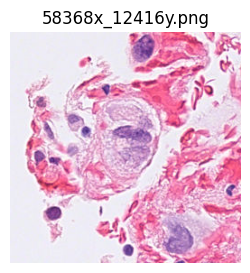

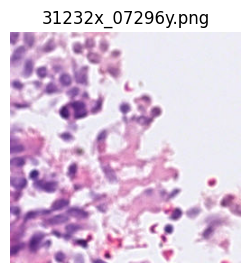

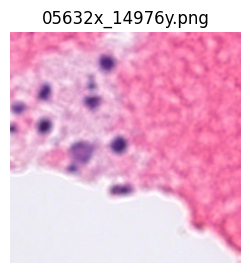

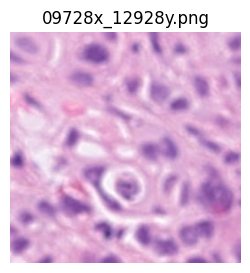

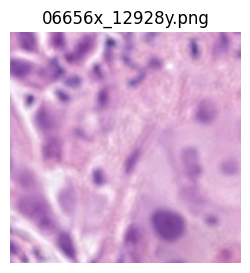

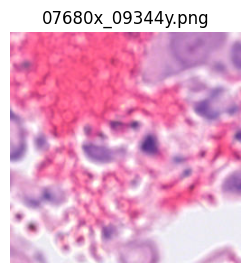

In [44]:
#visualizing the photos
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

tile_dir = "/root/.cache/outputs/preprocessing/output/PROV-000-000001.ndpi"

# collect image files
tile_files = [
    os.path.join(root, file)
    for root, _, files in os.walk(tile_dir)
    for file in files
    if file.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Number of image files found:", len(tile_files))

# choose 6 random tiles
selected = random.sample(tile_files, min(6, len(tile_files)))

for path in selected:
    img = Image.open(path)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(path))
    plt.show()

In [45]:
#part 3
!cat demo/3_load_tile_encoder.py

import timm
from PIL import Image
from torchvision import transforms
import torch
import os

assert "HF_TOKEN" in os.environ, "Please set the HF_TOKEN environment variable to your Hugging Face API token"

tile_encoder = timm.create_model("hf_hub:prov-gigapath/prov-gigapath", pretrained=True)

print("param #", sum(p.numel() for p in tile_encoder.parameters()))

transform = transforms.Compose(
    [
        transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ]
)

img_path = "images/prov_normal_000_1.png"
sample_input = transform(Image.open(img_path).convert("RGB")).unsqueeze(0)

with torch.no_grad():
    output = tile_encoder(sample_input).squeeze()
    print("Model output:", output.shape)
    print(output)

expected_output = torch.load("images/prov_normal_000_1.pt")
print("Expected output:", expected_output.sh

step three: Before you use our tile encoder on your actual data, here's one image and its known answer. Run it and make sure your installation produces the same answer.”

In [46]:
#step 3 run
!python demo/3_load_tile_encoder.py

param # 1134953984
Model output: torch.Size([1536])
tensor([-0.4881,  0.9477, -0.5380,  ..., -0.4984,  0.9778,  0.4101])
Expected output: torch.Size([1536])
tensor([-0.4881,  0.9477, -0.5380,  ..., -0.4984,  0.9778,  0.4101])


we can see that our outputs are close. so everything is running correctly.

In [47]:
#inspecting step 4
!cat demo/4_load_slide_encoder.py

import os
import gigapath.slide_encoder as slide_encoder

assert "HF_TOKEN" in os.environ, "Please set the HF_TOKEN environment variable to your Hugging Face API token"

# load from HuggingFace
# NOTE: CLS token is not trained during the pretraining
model_cls = slide_encoder.create_model("hf_hub:prov-gigapath/prov-gigapath", "gigapath_slide_enc12l768d", 1536, global_pool=False)

# load from HuggingFace with global pooling
model_global_pool = slide_encoder.create_model("hf_hub:prov-gigapath/prov-gigapath", "gigapath_slide_enc12l768d", 1536, global_pool=True)

# load from local file
# model = slide_encoder.create_model(
#    "/datadrive/gigapath/slide_encoder.pth",
#    "gigapath_slide_enc12l768d",
#    1536,
#)

# directly initialize a model using timm (random init)
# import timm
# model = timm.create_model("gigapath_slide_enc12l768d", pretrained=False, in_chans=1536)

# random init
# model = slide_encoder.create_model("", "gigapath_slide_enc12l768d", 1536)

print("param #", sum(p.numel

Step 4 also isn't yet feeding those 1068 embeddings into LongNet. It's primarily verifying/loading the slide encoder.

In [48]:
#running step 4
!python demo/4_load_slide_encoder.py

/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
dilated_ratio:  [1, 2, 4, 8, 16]
segment_length:  [1024, 5792, 32768, 185363, 1048576]
Number of trainable LongNet parameters:  85148160
Global Pooling: False
^C


In [49]:
#inspecting step 5
#since one tile becomes a 1536-dimensional embedding , 1536 dimensions is not easy to inspect, therefore step 5 is about principal component analysis and reducing the dimensions.
import json

with open("demo/gigapath_pca_visualization_timm.ipynb", "r") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    if cell["cell_type"] == "code":
        print(f"\n--- CODE CELL {i} ---")
        print("".join(cell["source"]))


--- CODE CELL 1 ---
import os

# Please set your Hugging Face API token
# os.environ["HF_TOKEN"] = ""

assert "HF_TOKEN" in os.environ, "Please set the HF_TOKEN environment variable to your Hugging Face API token"

--- CODE CELL 2 ---
import timm

model = timm.create_model("hf_hub:prov-gigapath/prov-gigapath", pretrained=True)

--- CODE CELL 3 ---
import torch
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from typing import List

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

def load_and_preprocess_image(image_path: str) -> Image.Image:
    with open(image_path, 

PCA
      ↓
identify tissue vs background
      ↓
reduce tissue features to 3 dimensions
      ↓
turn those 3 dimensions into RGB values
      ↓
visualize what different tissue regions look like
to the encoder




In [50]:
#runnning pca

%cd /content/prov-gigapath/demo

/content/prov-gigapath/demo


In [51]:
!jupyter nbconvert --to notebook --execute gigapath_pca_visualization_timm.ipynb \
    --output /content/gigapath_pca_visualization_output.ipynb

[NbConvertApp] Converting notebook gigapath_pca_visualization_timm.ipynb to notebook
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] Writing 1967024 bytes to /content/gigapath_pca_visualization_output.ipynb


we should fix the range of the loop since we have uploaded two photos and not four.

In [52]:

import nbformat

path = "/content/prov-gigapath/demo/gigapath_pca_visualization_timm.ipynb"

nb = nbformat.read(path, as_version=4)

for cell in nb.cells:
    if cell.cell_type == "code":
        cell.source = cell.source.replace(
            "for i in range(4):",
            "for i in range(len(transformed_imgs)):"
        )

nbformat.write(nb, path)

print("Notebook fixed.")

Notebook fixed.


In [53]:
#inspecting the files
from google.colab import files
files.download("/content/gigapath_pca_visualization_output.ipynb")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### PCA visualization of tile embeddings

The pretrained Prov-GigaPath tile encoder represents image patches as
1536-dimensional feature embeddings.

To inspect these learned representations, the demo applies PCA to the
intermediate features and reduces them to three principal components.

The resulting PCA components can be visualized spatially over the original
histology image. Different regions show different feature patterns,
indicating that the encoder captures spatial variation in tissue morphology.

The PCA components themselves do not correspond to predefined biological
classes. They represent major directions of variation in the learned
feature space.

In [54]:
#step 6 , runing prov gigapath
import json

with open("run_gigapath.ipynb", "r") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    if cell["cell_type"] == "code":
        print(f"\n--- CODE CELL {i} ---")
        print("".join(cell["source"]))


--- CODE CELL 1 ---
import os

# Please set your Hugging Face API token
# HF_TOKEN already set in Colab

assert "HF_TOKEN" in os.environ, "Please set the HF_TOKEN environment variable to your Hugging Face API token"

--- CODE CELL 3 ---
import huggingface_hub

local_dir = os.path.join(os.path.expanduser("~"), ".cache/")
huggingface_hub.hf_hub_download("prov-gigapath/prov-gigapath", filename="sample_data/PROV-000-000001.ndpi", local_dir=local_dir, force_download=True)
slide_path = os.path.join(local_dir, "sample_data/PROV-000-000001.ndpi")

--- CODE CELL 5 ---
from gigapath.pipeline import tile_one_slide

tmp_dir = 'outputs/preprocessing/'
tile_one_slide(slide_path, save_dir=tmp_dir, level=1)

--- CODE CELL 7 ---
import os

# load image tiles
slide_dir = "outputs/preprocessing/output/" + os.path.basename(slide_path) + "/"
image_paths = [os.path.join(slide_dir, img) for img in os.listdir(slide_dir) if img.endswith('.png')]

print(f"Found {len(image_paths)} image tiles")

--- CODE CELL 9

In [55]:
import nbformat

path = "/content/prov-gigapath/demo/run_gigapath.ipynb"

nb = nbformat.read(path, as_version=4)

for cell in nb.cells:
    if cell.cell_type == "code":
        cell.source = cell.source.replace(
            'os.environ["HF_TOKEN"] = "YOUR_HF_TOKEN"',
            '# HF_TOKEN already set in Colab'
        )

nbformat.write(nb, path)

print("run_gigapath notebook is ready.")

run_gigapath notebook is ready.


In [56]:
%cd /content/prov-gigapath/demo

!jupyter nbconvert --to notebook --execute run_gigapath.ipynb \
    --output /content/run_gigapath_output.ipynb

/content/prov-gigapath/demo
[NbConvertApp] Converting notebook run_gigapath.ipynb to notebook
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
2026-08-19 14:02:22.261604: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the ap

## Demo Status

The main stages of the Prov-GigaPath pipeline were successfully inspected and tested:

1. Loaded the pretrained tile encoder.
2. Generated tile-level embeddings.
3. Inspected the slide encoder.
4. Visualized intermediate tile features using PCA.
5. Tested the whole-slide preprocessing and inference pipeline.

During the final end-to-end execution of the demo, the Google Colab kernel died while processing the pipeline, most likely because the execution exceeded the available computational resources (RAM and/or GPU memory).

Because of this, the complete end-to-end run could not be finished in the current Colab environment.

However, the individual stages of the Prov-GigaPath pipeline were successfully explored and their intermediate outputs were inspected separately.